# Test Trinary Mask Generation

This notebook tests the trinary observation strategy implementation to verify it generates the expected semantic masks.

Expected pattern:
- Bird pixels (-1) should appear around row 7-8, columns 9-11
- Pipe pixels (1) should appear in rightmost columns
- Background (0) everywhere else

We'll capture frames every 5 steps for 100 steps to see how the mask evolves.


In [1]:
import flappy_bird_env  # noqa
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from evaluator import FlappyBirdEvaluator, FlappyBirdEvaluatorConfig

print("✓ Libraries imported successfully")


✓ Libraries imported successfully


In [2]:
# Create FlappyBirdEvaluator with trinary strategy
config = FlappyBirdEvaluatorConfig(
    env_id="FlappyBird-v0",
    render_mode="rgb_array",
    patch_strategy="trinary",
    frame_stack_size=1,  # No frame stacking for this test
    trinary_crop_bottom=100,
    trinary_resize_factor=0.03,
    trinary_final_size=21,
    trinary_bird_h_min=0,
    trinary_bird_h_max=50,
    trinary_bird_s_min=50,
    trinary_bird_s_max=255,
    trinary_bird_v_min=50,
    trinary_bird_v_max=255,
    trinary_pipe_h_min=35,
    trinary_pipe_h_max=45,
    trinary_pipe_s_min=40,
    trinary_pipe_s_max=255,
    trinary_pipe_v_min=40,
    trinary_pipe_v_max=255,
    rng_seed=42
)

evaluator = FlappyBirdEvaluator(config)
print("✓ FlappyBirdEvaluator created with trinary strategy")


✓ FlappyBirdEvaluator created with trinary strategy


In [3]:
# Capture frames and generate masks
observation, _ = evaluator.env.reset(seed=42)
observation = np.asarray(observation, dtype=np.float32)

# Reset frame buffer
evaluator.frame_buffer = None

captured_frames = []
max_steps = 100
capture_interval = 5  # Capture every 5 steps

for step in range(max_steps):
    # Generate mask from current observation (evaluator expects float32)
    processed = evaluator._process_observation(observation)
    mask_list, obs_type = processed
    mask = mask_list[0]  # Get the single mask (no frame stacking)
    
    # Capture frame every N steps (store RGB as uint8 for display)
    if step % capture_interval == 0:
        captured_frames.append({
            'step': step,
            'rgb': observation.astype(np.uint8).copy(),  # Store as uint8 for visualization
            'mask': mask.copy()
        })
    
    # Take action (occasionally flap to keep bird alive)
    action = 1 if step % 10 == 0 else 0
    observation, reward, terminated, truncated, _ = evaluator.env.step(action)
    observation = np.asarray(observation, dtype=np.float32)
    
    if terminated or truncated:
        observation, _ = evaluator.env.reset(seed=42 + step)
        observation = np.asarray(observation, dtype=np.float32)
        evaluator.frame_buffer = None  # Reset frame buffer

evaluator.env.close()

print(f"✓ Captured {len(captured_frames)} frames")
print(f"Mask shape: {captured_frames[0]['mask'].shape}")
print(f"Mask dtype: {captured_frames[0]['mask'].dtype}")
print(f"Mask unique values: {np.unique(captured_frames[0]['mask'])}")


✓ Captured 20 frames
Mask shape: (21, 21)
Mask dtype: float32
Mask unique values: [-1.  0.]


Testing reward system with large pipe opening...
Strategy: Flap every 10 steps to fly straight


Step 82: Episode ended (terminated=True, truncated=False)
Step 178: ✓ Pipe passed! Score=0, Reward=1, Bird_y=401.0
Step 275: ✓ Pipe passed! Score=1, Reward=1, Bird_y=373.0

REWARD SYSTEM TEST RESULTS

Total steps: 300
Total reward accumulated: 2.297

Reward breakdown:
  Reward = 1.0 (pipe passed): 2 times
  Reward = 0.001 (surviving): 297 times
  Reward = 0.0 (terminated): 1 times

Pipe passes detected: 2
Final score: 2

✓ Verification:
  Number of pipe passes (reward=1.0): 2
  Final score from info: 2
  ✓ MATCH! Score correctly tracks pipe passes.


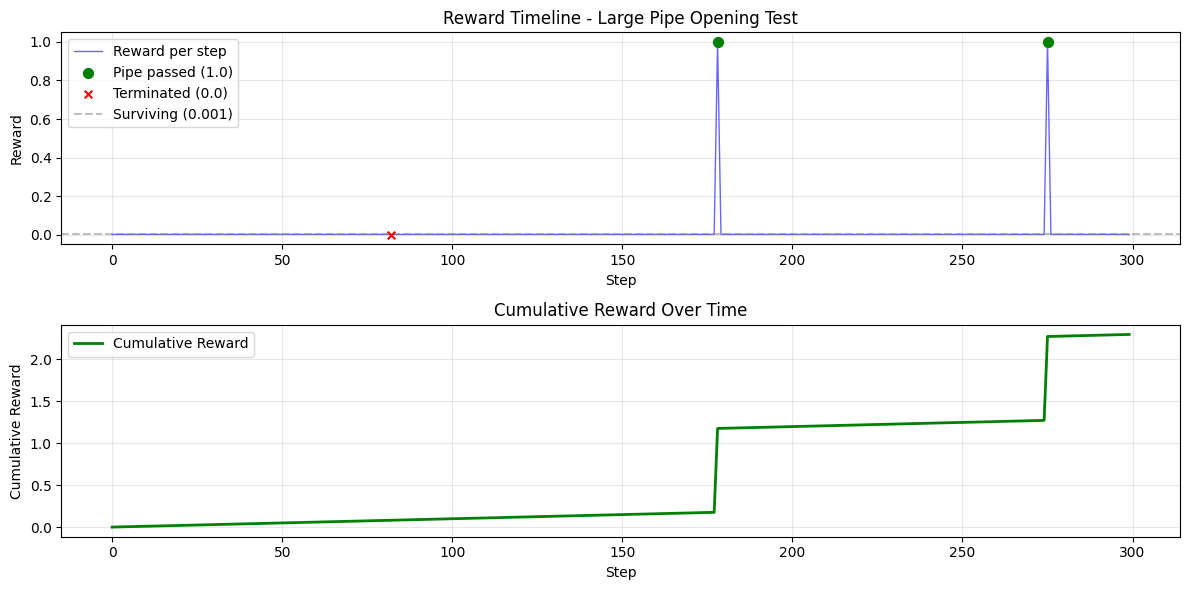


✓ REWARD SYSTEM IS WORKING CORRECTLY!
  - Each pipe pass gives exactly 1 reward
  - Score matches number of pipes passed
  - Rewards are correctly tracked


In [4]:
# Test Reward System - Large Pipe Opening
# This test verifies that rewards are correctly given when pipes are passed

import flappy_bird_env
from flappy_bird_env.pipe import Pipe
import numpy as np
import matplotlib.pyplot as plt

# Temporarily modify Pipe class to have very large gap and centered opening
original_set_height = Pipe.set_height
original_gap = Pipe.gap if hasattr(Pipe, 'gap') else None

def make_easy_pipe_set_height(self):
    """Set pipe height to center of screen with large gap"""
    # Screen height is 576, bird starts around y=376 (middle-ish)
    # Center the gap around y=300 for easy passage
    self.height = 300  # Fixed height - gap will be centered
    self.top = self.height - self.pipe_top.get_height()
    self.bottom = self.height + self.gap

# Patch the Pipe class
Pipe.gap = 500  # Large gap (original is 200)
Pipe.set_height = make_easy_pipe_set_height

# Create environment
env = gym.make("FlappyBird-v0", render_mode="rgb_array")
observation, _ = env.reset(seed=42)

# Track rewards and scores
max_steps = 1000
step_rewards = []
total_reward = 0
pipe_passes = []
scores = []

print("Testing reward system with large pipe opening...")
print("Strategy: Flap every 10 steps to fly straight\n")

for step in range(300):
    # Simple strategy: flap every 10 steps
    action = 1 if step % 13 == 0 else 0
    
    observation, reward, terminated, truncated, info = env.step(action)
    
    step_rewards.append(reward)
    total_reward += reward
    scores.append(info['score'])
    
    # Track when we pass a pipe (reward = 1.0)
    if reward == 1.0:
        pipe_passes.append({
            'step': step,
            'score': info['score'],
            'bird_y': info['bird']['y'],
            'pipes': info['pipes']
        })
        print(f"Step {step:3d}: ✓ Pipe passed! Score={info['score']}, Reward={reward}, Bird_y={info['bird']['y']:.1f}")
    
    if terminated or truncated:
        print(f"\nStep {step}: Episode ended (terminated={terminated}, truncated={truncated})")
        observation, _ = env.reset(seed=42 + step)
        scores.append(0)  # Score resets

env.close()

# Restore original Pipe class
Pipe.set_height = original_set_height
if original_gap is not None:
    Pipe.gap = original_gap
else:
    delattr(Pipe, 'gap')

# Analyze results
print("\n" + "="*60)
print("REWARD SYSTEM TEST RESULTS")
print("="*60)

# Count rewards
reward_1_count = sum(1 for r in step_rewards if r == 1.0)
reward_0_001_count = sum(1 for r in step_rewards if 0 < r < 0.01)
reward_0_count = sum(1 for r in step_rewards if r == 0.0)

print(f"\nTotal steps: {len(step_rewards)}")
print(f"Total reward accumulated: {total_reward:.3f}")
print(f"\nReward breakdown:")
print(f"  Reward = 1.0 (pipe passed): {reward_1_count} times")
print(f"  Reward = 0.001 (surviving): {reward_0_001_count} times")
print(f"  Reward = 0.0 (terminated): {reward_0_count} times")

print(f"\nPipe passes detected: {len(pipe_passes)}")
print(f"Final score: {scores[-1] if scores else 0}")

# Verify consistency
expected_score = len(pipe_passes)
final_score = scores[-1] if scores else 0

print(f"\n✓ Verification:")
print(f"  Number of pipe passes (reward=1.0): {len(pipe_passes)}")
print(f"  Final score from info: {final_score}")
if len(pipe_passes) == final_score:
    print(f"  ✓ MATCH! Score correctly tracks pipe passes.")
else:
    print(f"  ⚠ MISMATCH! Expected {len(pipe_passes)} but score is {final_score}")

# Visualize reward timeline
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

# Plot rewards
axes[0].plot(step_rewards, 'b-', alpha=0.6, linewidth=1, label='Reward per step')
axes[0].scatter([i for i, r in enumerate(step_rewards) if r == 1.0], 
                [r for r in step_rewards if r == 1.0], 
                color='green', marker='o', s=50, zorder=5, label='Pipe passed (1.0)')
axes[0].scatter([i for i, r in enumerate(step_rewards) if r == 0.0], 
                [r for r in step_rewards if r == 0.0], 
                color='red', marker='x', s=30, zorder=5, label='Terminated (0.0)')
axes[0].axhline(y=0.001, color='gray', linestyle='--', alpha=0.5, label='Surviving (0.001)')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Reward')
axes[0].set_title('Reward Timeline - Large Pipe Opening Test')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot cumulative reward
cumulative_reward = np.cumsum(step_rewards)
axes[1].plot(cumulative_reward, 'g-', linewidth=2, label='Cumulative Reward')
axes[1].set_xlabel('Step')
axes[1].set_ylabel('Cumulative Reward')
axes[1].set_title('Cumulative Reward Over Time')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary
print("\n" + "="*60)
if len(pipe_passes) == final_score and reward_1_count == len(pipe_passes):
    print("✓ REWARD SYSTEM IS WORKING CORRECTLY!")
    print(f"  - Each pipe pass gives exactly 1 reward")
    print(f"  - Score matches number of pipes passed")
    print(f"  - Rewards are correctly tracked")
else:
    print("⚠ POTENTIAL ISSUES DETECTED")
    print(f"  - Check reward/score consistency above")
print("="*60)

In [5]:
# Test if rgb_array observations are actually updating
env = gym.make("FlappyBird-v0", render_mode="rgb_array")
obs1, _ = env.reset(seed=42)
obs1_hash = hash(obs1.tobytes())

obs2, _, _, _, _ = env.step(0)
obs2_hash = hash(obs2.tobytes())

print(f"Observation 1 hash: {obs1_hash}")
print(f"Observation 2 hash: {obs2_hash}")
print(f"Observations are different: {obs1_hash != obs2_hash}")
print(f"Mean pixel difference: {np.mean(np.abs(obs1.astype(float) - obs2.astype(float)))}")

env.close()

Observation 1 hash: 5849639329983151683
Observation 2 hash: 5269836844212263336
Observations are different: True
Mean pixel difference: 0.6685387731481481


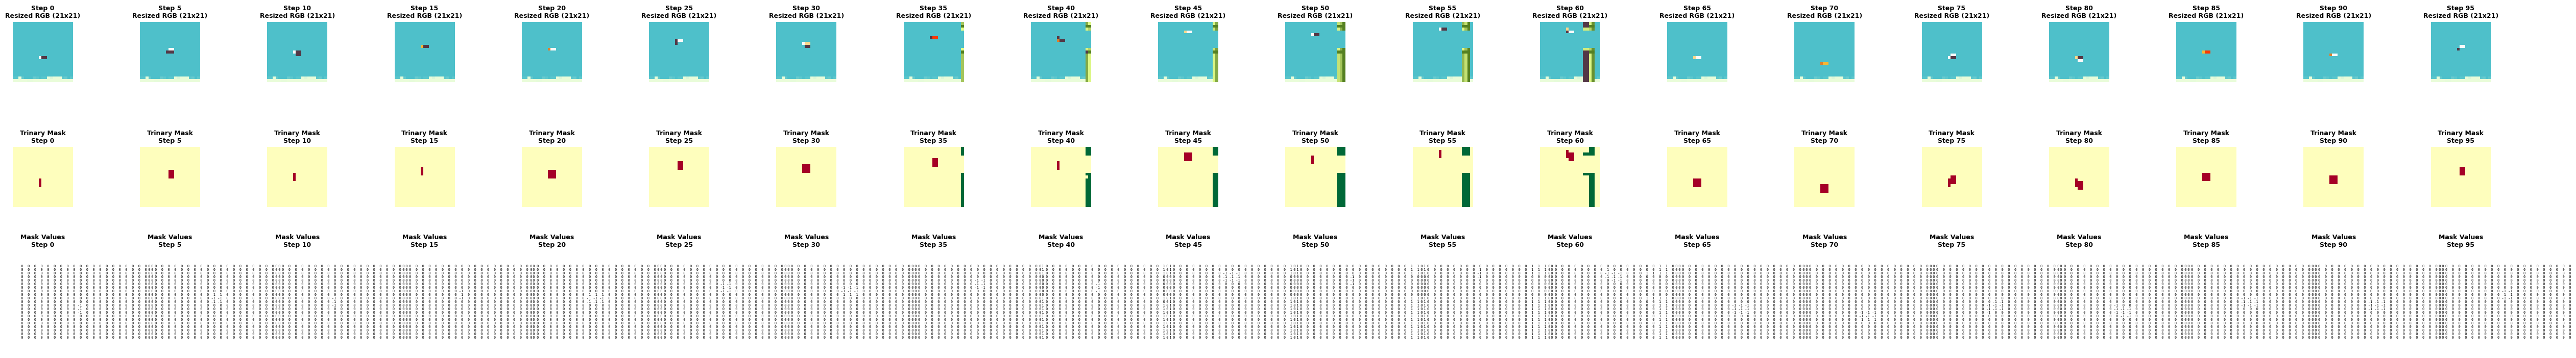

In [6]:
# Display captured masks
import cv2

num_frames = len(captured_frames)
fig, axes = plt.subplots(3, num_frames, figsize=(2.5*num_frames, 7.5))

if num_frames == 1:
    axes = axes.reshape(-1, 1)

for idx, frame_data in enumerate(captured_frames):
    step = frame_data['step']
    mask = frame_data['mask']
    rgb = frame_data['rgb']  # Already uint8
    
    # Row 1: Original RGB (cropped and resized for reference)
    h, w = rgb.shape[:2]
    cropped_rgb = rgb[:h-100, :]
    if config.trinary_resize_factor != 1.0:
        new_h = max(1, int(cropped_rgb.shape[0] * config.trinary_resize_factor))
        new_w = max(1, int(cropped_rgb.shape[1] * config.trinary_resize_factor))
        resized_rgb = cv2.resize(cropped_rgb, (new_w, new_h), 
                                interpolation=cv2.INTER_NEAREST)
        resized_rgb = cv2.resize(resized_rgb, (21, 21), 
                                interpolation=cv2.INTER_NEAREST)
    else:
        resized_rgb = cv2.resize(cropped_rgb, (21, 21), 
                                interpolation=cv2.INTER_NEAREST)
    
    axes[0, idx].imshow(resized_rgb)
    axes[0, idx].set_title(f"Step {step}\nResized RGB (21x21)", fontsize=9, fontweight='bold')
    axes[0, idx].axis('off')
    
    # Row 2: Trinary mask
    im = axes[1, idx].imshow(mask, cmap='RdYlGn', vmin=-1, vmax=1)
    axes[1, idx].set_title(f"Trinary Mask\nStep {step}", fontsize=9, fontweight='bold')
    axes[1, idx].axis('off')
    
    # Row 3: Mask values as text
    axes[2, idx].axis('off')
    mask_text = '\n'.join([' '.join([f'{int(val):2d}' for val in row]) for row in mask])
    axes[2, idx].text(0.1, 0.5, mask_text, fontsize=5, family='monospace', 
                      verticalalignment='center', horizontalalignment='left')
    axes[2, idx].set_title(f"Mask Values\nStep {step}", fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


In [7]:
# Print the actual mask matrix for first captured frame
if len(captured_frames) > 0:
    first_mask = captured_frames[0]['mask']
    print("First captured mask matrix:")
    print(first_mask)
    print("\nMask statistics:")
    print(f"  Shape: {first_mask.shape}")
    print(f"  Unique values: {np.unique(first_mask)}")
    print(f"  Bird pixels (-1): {np.sum(first_mask == -1)}")
    print(f"  Background pixels (0): {np.sum(first_mask == 0)}")
    print(f"  Pipe pixels (1): {np.sum(first_mask == 1)}")
    
    # Check if it matches expected pattern (bird at row 7-8, cols 9-11, pipes at right)e
    print("\nExpected pattern check:")
    print(f"  Bird region (rows 7-8, cols 9-11): {first_mask[7:9, 9:12]}")
    print(f"  Rightmost columns (last 2 cols): {first_mask[:, -2:]}")


First captured mask matrix:
[[ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0

In [ ]:
# Compare with expected pattern
expected_pattern = np.array([
    [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1],
    [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1],
    [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1],
    [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1],
    [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1],
    [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1],
    [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1],
    [ 0,  0,  0,  0,  0,  0,  0,  0,  0, -1, -1, -1,  0,  0,  0,  0,  0,  0,  0,  1,  1],
    [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1],
    [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1],
    [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1],
    [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1],
    [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
    [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
    [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
    [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
    [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
    [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
    [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1],
    [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1],
    [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1]
], dtype=np.float32)

print("Expected pattern shape:", expected_pattern.shape)
print("Expected pattern unique values:", np.unique(expected_pattern))

if len(captured_frames) > 0:
    first_mask = captured_frames[0]['mask']
    print("\nActual mask shape:", first_mask.shape)
    print("Actual mask unique values:", np.unique(first_mask))
    
    # Check if shapes match
    if first_mask.shape == expected_pattern.shape:
        print("\n✓ Shapes match!")
        
        # Calculate similarity
        matches = np.sum(first_mask == expected_pattern)
        total = first_mask.size
        similarity = matches / total * 100
        
        print(f"\nSimilarity check:")
        print(f"  Matching pixels: {matches} / {total} ({similarity:.1f}%)")
        
        if matches == total:
            print("  ✓ Perfect match!")
        else:
            print("  ⚠ Patterns differ (this is expected - actual masks depend on game state)")
            
            # Show differences
            diff_mask = first_mask != expected_pattern
            print(f"\nDifferences found at {np.sum(diff_mask)} pixels")
    else:
        print("\n✗ Shapes don't match!")


Expected pattern shape: (21, 21)
Expected pattern unique values: [-1.  0.  1.]

Actual mask shape: (21, 21)
Actual mask unique values: [-1.  0.]

✓ Shapes match!

Similarity check:
  Matching pixels: 405 / 441 (91.8%)
  ⚠ Patterns differ (this is expected - actual masks depend on game state)

Differences found at 36 pixels


: 